# Classification

## Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams["figure.constrained_layout.use"] = True
from sklearn.metrics import accuracy_score,classification_report
from sklearn.datasets import make_moons,make_blobs,make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from dataset import CovtypeDataset as Dataset
from eda.eda import EDA
from classification.pipeline import get_pipeline


# Logistic regression
from classification.logistic_regression.softmax import SoftmaxClassifier
from classification.logistic_regression.sigmoid import SigmoidClassifier
from classification.logistic_regression.irls import IRLSClassifier

# Discriminant Analysis
from classification.lda.lda import LDA
from classification.lda.qda import QDA
from classification.lda.fisher_ratio import fisher_ratio

# Perceptron and Regularization
from classification.perceptron_logreg.perceptron import Perceptron
from classification.perceptron_logreg.class_weighted import WeightedSoftmaxClassifier
from classification.perceptron_logreg.lambda_selection import select_best_lambda

# Advanced
from classification.advanced.probit import ProbitClassifier
from classification.advanced.laplace import LaplaceApprox
from classification.advanced.kernel_logistic import KernelLogisticRegression

from evaluation.evaluator import Evaluator
from evaluation.visualizer import Visualizer

## Dataset

In [2]:
d = Dataset()
d.split()

In [ ]:
eda = EDA(d)

### Missing values

In [ ]:
print(eda.missing_values())

### Descriptive statistics

In [ ]:
result = eda.descriptive_stats_numeric_features()
# result = result.round(2)
# result.to_csv("covtype-desc.csv")
print(result)

### Target distribution

In [ ]:
result = eda.target_distribution()
# result.to_csv("covtype-target-count.csv")
print(result)

In [ ]:
eda.plot_target_distribution()
plt.show()

### Numeric features

In [ ]:
figs = eda.plot_numeric_features()
for fig in figs:
    fig.show()

### Categorical features

In [ ]:
figs = eda.plot_categorical_features()
for fig in figs:
    fig.show()

### Numeric features vs Target

In [ ]:
figs = eda.plot_numeric_vs_target()
for fig in figs:
    fig.show()

### Target distribution by wilderness area

In [ ]:
eda.plot_cover_type_distribution_by_wilderness_area()
plt.show()

## Models

### Logistic regression

#### Sigmoid

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# dataset
X, y = make_classification(
    n_samples=500_000,
    n_features=10,
    n_informative=6,
    n_classes=2,
    random_state=42
)

# split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# model
model = SigmoidClassifier(
    max_iter=20,
    step_size=4,
    batch_size=1024
)

# fit
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

# accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Acc = {acc:.4f}")

# ===== PLOT =====
epochs = range(len(model.train_loss_history_))

# 1. loss vs epoch
plt.figure(layout="constrained")
plt.plot(epochs, model.train_loss_history_, label="train")
plt.plot(epochs, model.val_loss_history_, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# 2. loss vs time
plt.figure(layout="constrained")
plt.plot(model.time_history_, model.train_loss_history_, label="train")
plt.plot(model.time_history_, model.val_loss_history_, label="val")
plt.xlabel("Time (s)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()

#### Newton-Raphson IRLS

In [ ]:
# model
model = IRLSClassifier()

# fit
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

# accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Acc = {acc:.4f}")

# ===== PLOT =====
epochs = range(len(model.train_loss_history_))

# 1. loss vs epoch
plt.figure(layout="constrained")
plt.plot(epochs, model.train_loss_history_, label="train")
plt.plot(epochs, model.val_loss_history_, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# 2. loss vs time
plt.figure(layout="constrained")
plt.plot(model.time_history_, model.train_loss_history_, label="train")
plt.plot(model.time_history_, model.val_loss_history_, label="val")
plt.xlabel("Time (s)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()

#### Softmax

In [ ]:
softmax = get_pipeline(SoftmaxClassifier())
softmax.fit(d.X_train, d.y_train)
y_pred = softmax.predict(d.X_test)
y_true = d.y_test
acc = accuracy_score(y_true, y_pred)
print(f"Acc = {acc:.4f}")

#### OvR, OvO and Softmax

In [ ]:
models = {
    "OvR Sigmoid": get_pipeline(OneVsRestClassifier(SigmoidClassifier())),
    "OvO Sigmoid": get_pipeline(OneVsOneClassifier(SigmoidClassifier())),
    "Softmax": get_pipeline(SoftmaxClassifier()),
}

In [ ]:
evaluator = Evaluator()
result = evaluator.compare_models_test(
    models,
    d.X_train,
    d.y_train,
    d.X_test,
    d.y_test
)

# result = result.round(4)
# result.to_csv("ovr-ovo-softmax-compare-test.csv", index=False)

print(result)

In [ ]:
def plot_precision_and_confusion(result_df, class_names=None):
    """
    Returns
    -------
    fig : matplotlib.figure.Figure
    """

    n_models = len(result_df)

    first_prec = np.array(result_df.iloc[0]["Precision_per_class"])
    n_classes = len(first_prec)

    if class_names is None:
        class_names = [f"Class {i}" for i in range(n_classes)]

    fig, axes = plt.subplots(
        2, n_models,
        figsize=(6 * n_models, 10)
    )

    # ===================== FIG TITLE =====================
    fig.suptitle(
        "Model Comparison: Precision per Class & Confusion Matrix",
        fontsize=16
    )

    # fix shape when only 1 model
    if n_models == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, row in result_df.iterrows():
        model_name = row["Model"]

        precision = np.array(row["Precision_per_class"])
        cm = np.array(row["Confusion Matrix"])

        # ===================== PRECISION =====================
        ax1 = axes[0, i]
        ax1.bar(range(n_classes), precision)
        ax1.set_title(f"{model_name}\nPrecision per Class")
        ax1.set_xlabel("Class")
        ax1.set_ylabel("Precision")
        ax1.set_xticks(range(n_classes))
        ax1.set_xticklabels(class_names)
        ax1.set_ylim(0, 1)

        # ===================== CONFUSION MATRIX =====================
        ax2 = axes[1, i]
        im = ax2.imshow(cm, interpolation="nearest", cmap="Blues")

        ax2.set_title(f"{model_name}\nConfusion Matrix")
        ax2.set_xlabel("Predicted")
        ax2.set_ylabel("True")

        ax2.set_xticks(range(n_classes))
        ax2.set_yticks(range(n_classes))
        ax2.set_xticklabels(class_names)
        ax2.set_yticklabels(class_names)

        # annotate values
        for r in range(n_classes):
            for c in range(n_classes):
                ax2.text(c, r, str(cm[r, c]),
                         ha="center", va="center")


    return fig

In [ ]:
plot_precision_and_confusion(result, d.classes)
plt.show()

### LDA & QDA

#### LDA

In [ ]:
model = get_pipeline(LDA(n_components=2))
model.fit(d.X_train, d.y_train)

In [ ]:
y_pred = model.predict(d.X_test)
y_true = d.y_test
acc = accuracy_score(y_true, y_pred)
print(f"Acc = {acc:.4f}")

#### Decision Boundary 2D

In [ ]:
model.named_steps["predictor"].plot2D(d.X_train, d.y_train)

#### QDA

In [ ]:
model = get_pipeline(QDA())
model.fit(d.X_train, d.y_train)

In [ ]:
y_pred = model.predict(d.X_test)
y_true = d.y_test
acc = accuracy_score(y_true, y_pred)
print(f"Acc = {acc:.4f}")

#### Fisher ratio

In [ ]:
J_scores = fisher_ratio(d.X_train, d.y_train)
df_ranking = pd.DataFrame({
    'Feature': d.feature_names,
    'Fisher_Ratio': J_scores
}).sort_values(by='Fisher_Ratio', ascending=False).reset_index(drop=True)
print(df_ranking)

### Perceptron & Regularization

#### Perceptron

In [ ]:
# ===== 1. LINEAR DATA =====
result = make_blobs(n_samples=200, centers=2, random_state=42)
X_linear, y_linear = result[:2]
y_linear = np.where(y_linear == 0, -1, 1)

model1 = Perceptron(lr=0.01, epochs=50)
model1.fit(X_linear, y_linear)

# ===== 2. NON-LINEAR DATA =====
X_non, y_non = make_circles(n_samples=200, noise=0.1, factor=0.5)
y_non = np.where(y_non == 0, -1, 1)

model2 = Perceptron(lr=0.01, epochs=50)
model2.fit(X_non, y_non)

# ===== PLOT =====
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear,s=5)
# draw decision boundary
x_vals = np.linspace(X_linear[:, 0].min(), X_linear[:, 0].max(), 100)
y_vals = -(model1.w[0] * x_vals + model1.b) / model1.w[1]
plt.plot(x_vals, y_vals, linewidth=2)
plt.title("Linear Separable Data (Blobs)")

plt.subplot(2, 2, 2)
plt.scatter(X_non[:, 0], X_non[:, 1], c=y_non,s=5)
x_vals = np.linspace(X_non[:, 0].min(), X_non[:, 0].max(), 100)
y_vals = -(model2.w[0] * x_vals + model2.b) / model1.w[1]
plt.plot(x_vals, y_vals, linewidth=2)
plt.title("Non-linear Data")

plt.subplot(2, 2, 3)
plt.plot(model1.errors_, marker='o', markersize=3, linewidth=1)
plt.title("Linear Data (Converges)")
plt.xlabel("Epoch")
plt.ylabel("Error rate")
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(model2.errors_, marker='o', markersize=3, linewidth=1)
plt.title("Non-linear Data (Not Converged)")
plt.xlabel("Epoch")
plt.ylabel("Error rate")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===== PRINT =====
print("Linear:", "Converged" if model1.errors_[-1] == 0 else "Not converged")
print("Non-linear:", "Converged" if model2.errors_[-1] == 0 else "Not converged")

#### Regularization

In [ ]:

# ===== L1 Logistic Regression =====
model_l1 = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.01, 
    max_iter=2000
)
model_l1.fit(X_train, y_train)

# ===== L2 Logistic Regression =====
model_l2 = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000
)
model_l2.fit(X_train, y_train)

# ===== Accuracy =====
acc_l1 = accuracy_score(y_test, model_l1.predict(X_test))
acc_l2 = accuracy_score(y_test, model_l2.predict(X_test))

# ===== Sparsity =====
w_l1 = model_l1.coef_
w_l2 = model_l2.coef_

sparsity_l1 = np.mean(np.abs(w_l1) < 1e-6)
sparsity_l2 = np.mean(np.abs(w_l2) < 1e-6)

print("=== RESULTS ===")
print("L1 Accuracy:", acc_l1)
print("L2 Accuracy:", acc_l2)
print("L1 Sparsity:", sparsity_l1)
print("L2 Sparsity:", sparsity_l2)

#### Stratified k-fold CV

In [3]:
X = d.X
y = d.y
print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

# ===== Lambda=====
lambdas = [0.001, 0.01, 0.1, 1, 10]

# ===== Function choose best lambda =====
best_lambda, best_score = select_best_lambda(X, y, lambdas)

print("\n=== RESULT ===")
print("Best lambda:", best_lambda)
print("Best log loss:", best_score)

Dataset shape: (581012, 54)
Class distribution: [     0 211840 283301  35754   2747   9493  17367  20510]


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 0.001, Log Loss = 0.6290


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 0.01, Log Loss = 0.6290


...

Lambda = 0.1, Log Loss = 0.6290


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 1, Log Loss = 0.6290


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

Lambda = 10, Log Loss = 0.6292

=== RESULT ===
Best lambda: 0.01
Best log loss: 0.6289983569404619


#### Class-weighted loss


In [13]:
# ===== SCALE DATA (RẤT QUAN TRỌNG) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ===== 1. Logistic Regression (baseline - KHÔNG weight) =====
print("========== LOGISTIC REGRESSION (NO CLASS WEIGHT) ==========")

logistic_model = LogisticRegression(
    max_iter=2000,      # tăng để hội tụ
    n_jobs=-1           # nhanh hơn (nếu CPU hỗ trợ)
)

logistic_model.fit(X_train_scaled, y_train)
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=4, zero_division=0))


# ===== 2. Logistic Regression (CÓ class_weight) =====
print("\n========== LOGISTIC REGRESSION (BALANCED) ==========")

logistic_balanced = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    n_jobs=-1
)

logistic_balanced.fit(X_train_scaled, y_train)
y_pred_bal = logistic_balanced.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal, digits=4, zero_division=0))


# ===== 3. Weighted Softmax (custom) =====
print("\n========== WEIGHTED SOFTMAX (CUSTOM) ==========")

model_weight = WeightedSoftmaxClassifier(
    lr=0.05,
    max_iter=500,
    batch_size=2048   # giúp ổn định hơn với dataset lớn
)

model_weight.fit(X_train_scaled, y_train)
y_pred_w = model_weight.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_w))
print(classification_report(y_test, y_pred_w, digits=4, zero_division=0))


# ===== In class weights =====
print("\n========== CLASS WEIGHTS (CUSTOM MODEL) ==========")
for i, w in enumerate(model_weight.class_weights_):
    print(f"Class {model_weight.classes_[i]}: weight = {w:.4f}")

========== LOGISTIC REGRESSION (NO CLASS WEIGHT) ==========


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.667030971661661


d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Hoc_May\supervised-learning-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

              precision    recall  f1-score   support

           1     0.6615    0.6734    0.6674     42368
           2     0.6907    0.7857    0.7351     56660
           3     0.5884    0.5781    0.5832      7151
           4     0.0000    0.0000    0.0000       549
           5     0.0000    0.0000    0.0000      1899
           6     0.3475    0.0236    0.0442      3474
           7     0.1844    0.0609    0.0916      4102

    accuracy                         0.6670    116203
   macro avg     0.3532    0.3031    0.3031    116203
weighted avg     0.6310    0.6670    0.6422    116203


========== WEIGHTED SOFTMAX (CLASS-WEIGHTED) ==========


KeyboardInterrupt: 

## Advanced

### Probit

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


class Data:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test


def make_classification_data(test_size=0.3, random_state=42):
    # ===== generate blobs =====
    centers = [[-4, 0], [0, 2]]
    X, y = make_blobs(
        n_samples=1000,
        centers=centers,
        cluster_std=2,
        random_state=40
    )

    # ===== linear transformation (tạo correlation + rotate) =====
    transformation = [[0.4, 0.3], [-0.4, 0.7]]
    X = np.dot(X, transformation)

    # ===== split =====
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    return Data(X_train, X_test, y_train, y_test)

bd = make_classification_data()

In [ ]:
def plot_decision_boundary_2features(
    model, X, y, f1=0, f2=1, resolution=200, title="Decision Boundary"
):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots()  # ✅ tạo figure mới

    x_min, x_max = X[:, f1].min() - 1, X[:, f1].max() + 1
    y_min, y_max = X[:, f2].min() - 1, X[:, f2].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    # giữ các feature khác = mean
    X_mean = np.mean(X, axis=0)
    grid = np.tile(X_mean, (xx.size, 1))
    grid[:, f1] = xx.ravel()
    grid[:, f2] = yy.ravel()

    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(
        X[:, f1], X[:, f2],
        c=y, s=20, edgecolor="k", cmap="coolwarm"
    )

    ax.set_xlabel(f"Feature {f1}")
    ax.set_ylabel(f"Feature {f2}")
    ax.set_title(title)

    return fig


def plot_probability_2features(
    model, X, y, f1=0, f2=1, class_idx=1,
    resolution=200, title="Probability"
):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots()  # ✅ quan trọng

    x_min, x_max = X[:, f1].min() - 1, X[:, f1].max() + 1
    y_min, y_max = X[:, f2].min() - 1, X[:, f2].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    X_mean = np.mean(X, axis=0)
    grid = np.tile(X_mean, (xx.size, 1))
    grid[:, f1] = xx.ravel()
    grid[:, f2] = yy.ravel()

    Z = model.predict_proba(grid)[:, class_idx].reshape(xx.shape)

    contour = ax.contourf(xx, yy, Z, levels=50, cmap="viridis")

    ax.scatter(
        X[:, f1], X[:, f2],
        c=y, s=20, edgecolor="k", cmap="viridis"
    )

    # ✅ gắn colorbar đúng figure + axis
    fig.colorbar(contour, ax=ax, label=f"p(class={class_idx})")

    ax.set_xlabel(f"Feature {f1}")
    ax.set_ylabel(f"Feature {f2}")
    ax.set_title(title)

    return fig


sigmoid = get_pipeline(SigmoidClassifier())
sigmoid.fit(data.X_train, data.y_train)

probit = get_pipeline(ProbitClassifier())
probit.fit(data.X_train, data.y_train)

#### Decision boundary

In [ ]:
plot_decision_boundary_2features(sigmoid, bd.X_train, bd.y_train, f1=0, f2=1, title="Sigmoid Decision Boundary")
plt.show()

In [ ]:
plot_decision_boundary_2features(probit, bd.X_train, bd.y_train, f1=0, f2=1, title="Probit Decision Boundary")
plt.show()

#### Predict probability

In [ ]:
plot_probability_2features(sigmoid, bd.X_train, bd.y_train, f1=0, f2=1, class_idx=1, title="Sigmoid Probability Class 1")
plt.show()

In [ ]:
plot_probability_2features(probit, bd.X_train, bd.y_train, f1=0, f2=1, class_idx=1, title="Probit Probability Class 1")
plt.show()

#### Noise sensitivity

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.base import clone


def compute_cls_metrics(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    metrics = (acc, f1, prec, rec)

    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba)
        except:
            auc = np.nan
        metrics = metrics + (auc,)
    else:
        metrics = metrics + (np.nan,)

    return metrics


def label_noise_sensitivity_df(models, data, noise_ratio=0.1, seed=42):
    rng = np.random.RandomState(seed)
    rows = []

    classes = np.unique(data.y_train)

    # ===== CLEAN TRAIN =====
    clean_scores = {}

    for name, model in models.items():
        m = clone(model)
        m.fit(data.X_train, data.y_train)

        y_pred = m.predict(data.X_test)

        y_proba = None
        if hasattr(m, "predict_proba"):
            y_proba = m.predict_proba(data.X_test)
            if y_proba.shape[1] == 2:
                y_proba = y_proba[:, 1]

        clean_scores[name] = compute_cls_metrics(
            data.y_test, y_pred, y_proba
        )

    # ===== ADD LABEL NOISE =====
    y_train_noisy = data.y_train.copy()

    n_flip = int(len(y_train_noisy) * noise_ratio)
    flip_idx = rng.choice(len(y_train_noisy), n_flip, replace=False)

    if len(classes) == 2:
        y_train_noisy[flip_idx] = 1 - y_train_noisy[flip_idx]
    else:
        y_train_noisy[flip_idx] = rng.choice(classes, size=n_flip)

    # ===== NOISY TRAIN =====
    noisy_scores = {}

    for name, model in models.items():
        m = clone(model)
        m.fit(data.X_train, y_train_noisy)

        y_pred = m.predict(data.X_test)

        y_proba = None
        if hasattr(m, "predict_proba"):
            y_proba = m.predict_proba(data.X_test)
            if y_proba.shape[1] == 2:
                y_proba = y_proba[:, 1]

        noisy_scores[name] = compute_cls_metrics(
            data.y_test, y_pred, y_proba
        )

    # ===== BUILD DATAFRAME =====
    for name in models.keys():
        (cacc, cf1, cprec, crec, cauc) = clean_scores[name]
        (nacc, nf1, nprec, nrec, nauc) = noisy_scores[name]

        rows.append({
            "Model": name,

            # Accuracy
            "Acc_clean": cacc,
            "Acc_noisy": nacc,
            "Acc_sensitivity": (cacc - nacc) / (cacc + 1e-8),

            # F1
            "F1_clean": cf1,
            "F1_noisy": nf1,
            "F1_sensitivity": (cf1 - nf1) / (cf1 + 1e-8),

            # Precision
            "Precision_clean": cprec,
            "Precision_noisy": nprec,
            "Precision_sensitivity": (cprec - nprec) / (cprec + 1e-8),

            # Recall
            "Recall_clean": crec,
            "Recall_noisy": nrec,
            "Recall_sensitivity": (crec - nrec) / (crec + 1e-8),

            # AUC
            "AUC_clean": cauc,
            "AUC_noisy": nauc,
            "AUC_sensitivity": (cauc - nauc) if not np.isnan(cauc) else np.nan,
        })

    return pd.DataFrame(rows)

In [ ]:
models = {
    "Sigmoid": get_pipeline(SigmoidClassifier()),
    "Probit": get_pipeline(ProbitClassifier()),
}

df = label_noise_sensitivity_df(models, bd)
# df = df.round(4)
# df.to_csv("regression-irls-outliers-sensitivity.csv", index=False)

print(df)

### Laplace approximation

In [ ]:
centers = [[-4, 0], [0, 2]]
X, y = make_blobs(n_samples=1_000, centers=centers, cluster_std=2, random_state=40)
transformation = [[0.4, 0.3], [-0.4, 0.7]]
X = np.dot(X, transformation)

In [ ]:
# ===== Train Sigmoid (Logistic) =====
model = SigmoidClassifier()
list(model._fit(X, y))

# ===== Laplace Approximation =====
laplace = LaplaceApprox(model)
laplace.fit(X)

# ===== Plot decision boundary + uncertainty =====
fig, ax = plt.subplots(figsize=(6,6))
laplace.decision_boundary_sigma(X, y, ax=ax)
plt.show()

### Kernel Logistic Regression

In [ ]:
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

In [ ]:
linear_model = LogisticRegression()
linear_model.fit(X, y)

In [ ]:
kernel_model = KernelLogisticRegression(gamma=5, lr=0.01, epochs=500)
kernel_model.fit(X, y)

In [ ]:
DecisionBoundaryDisplay.from_estimator(
    linear_model,
    X,
    response_method="predict",
    alpha=0.3,
    grid_resolution=200
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.title("Linear Logistic Regression")
plt.show()

In [ ]:
DecisionBoundaryDisplay.from_estimator(
    kernel_model,
    X,
    response_method="predict",
    alpha=0.3,
    grid_resolution=200
)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
plt.title("Kernel Logistic Regression (RBF)")
plt.show()

#### VC_dimension

===== VC DIMENSION (Covtype Dataset) =====
Number of features (D): 54
Estimated VC dimension: 55

===== SRM EXPERIMENT =====
C =  0.0010 | Train = 0.7174 | Val = 0.7161 | Test = 0.7199
C =  0.0100 | Train = 0.7234 | Val = 0.7219 | Test = 0.7257
C =  0.1000 | Train = 0.7247 | Val = 0.7228 | Test = 0.7264
C =  1.0000 | Train = 0.7246 | Val = 0.7227 | Test = 0.7265
C = 10.0000 | Train = 0.7246 | Val = 0.7229 | Test = 0.7262
C = 100.0000 | Train = 0.7246 | Val = 0.7228 | Test = 0.7264

===== SRM RESULT =====
Best C (from validation): 10.0
Best Validation Accuracy: 0.7229
Test Accuracy (best model): 0.7262


C:\Users\Admin\AppData\Local\Temp\ipykernel_17284\2353322269.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


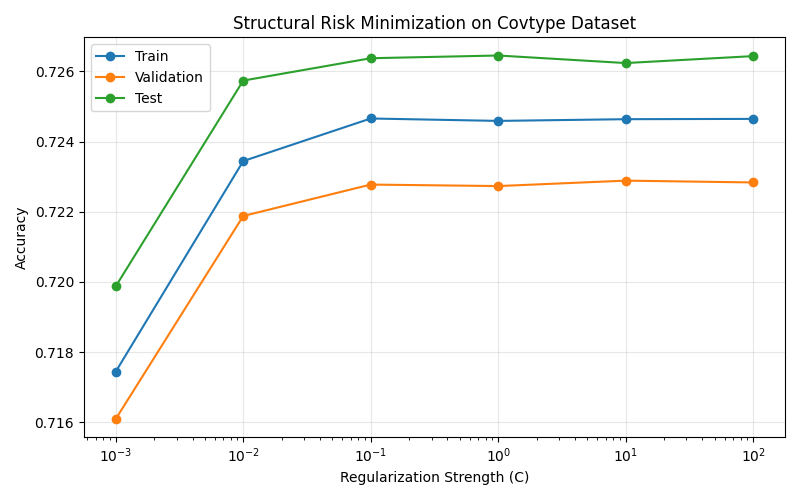

In [16]:
d.y = np.where(d.y == 1, 1, 0)
X_train, y_train = d.X_train, d.y_train
X_val, y_val     = d.X_val, d.y_val
X_test, y_test   = d.X_test, d.y_test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ===== VC dimension =====
D = d.n_features
vc_dim = D + 1

print("===== VC DIMENSION (Covtype Dataset) =====")
print(f"Number of features (D): {D}")
print(f"Estimated VC dimension: {vc_dim}")

# ===== SRM =====
C_values = np.logspace(-3, 2, 6)  # đẹp hơn list thường

train_acc, val_acc, test_acc = [], [], []

print("\n===== SRM EXPERIMENT =====")

for C in C_values:
    model = LogisticRegression(C=C, max_iter=500)

    model.fit(X_train, y_train)

    train = accuracy_score(y_train, model.predict(X_train))
    val   = accuracy_score(y_val, model.predict(X_val))
    test  = accuracy_score(y_test, model.predict(X_test))

    train_acc.append(train)
    val_acc.append(val)
    test_acc.append(test)

    print(f"C = {C:>7.4f} | Train = {train:.4f} | Val = {val:.4f} | Test = {test:.4f}")

# ===== Select best model =====
best_idx = np.argmax(val_acc)
best_C = C_values[best_idx]

print("\n===== SRM RESULT =====")
print(f"Best C (from validation): {best_C}")
print(f"Best Validation Accuracy: {val_acc[best_idx]:.4f}")
print(f"Test Accuracy (best model): {test_acc[best_idx]:.4f}")

# ===== Plot =====
plt.figure(figsize=(8, 5))

plt.plot(C_values, train_acc, marker='o', label="Train")
plt.plot(C_values, val_acc, marker='o', label="Validation")
plt.plot(C_values, test_acc, marker='o', label="Test")

plt.xscale('log')
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Accuracy")
plt.title("Structural Risk Minimization on Covtype Dataset")

plt.legend()          
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
models = {
    "Softmax": get_pipeline(SoftmaxClassifier()),
    "LDA": get_pipeline(LDA()),
    "QDA": get_pipeline(QDA()),
    "Weighted Softmax": get_pipeline(WeightedSoftmaxClassifier())
}

In [ ]:
evaluator = Evaluator()

# ====================== CV ======================

cv_result = evaluator.compare_models_cv(
    models,
    d.X_train,
    d.y_train
)

# cv_test = cv_result.round(4)
# cv_result.to_csv("classification-compare-models-cv.csv", index=False)
print(cv_result)


# ====================== TEST ======================

test_result = evaluator.compare_models_test(
    models,
    d.X_train,
    d.y_train,
    d.X_test,
    d.y_test
)

# test_result = test_result.round(4)
# test_result.to_csv("classification-compare-models-test.csv", index=False)

print(test_result)


# ====================== STATISTICAL TEST ======================

# ⚠️ IMPORTANT: fit trước trên train
for model in models.values():
    model.fit(d.X_train, d.y_train)

stat_result = evaluator.compare_models_statistical(
    models,
    d.X_test,
    d.y_test
)

# stat_result = stat_result.round(4)
# stat_result.to_csv("classification-mcnemar-test.csv", index=False)

print(stat_result)

In [ ]:
def plot_all_evaluation(visualizer, models, class_names, X_test, y_test):

    # =========================================================
    # BUILD models_results (NO FIT, ONLY PREDICT)
    # =========================================================
    models_results = {}

    for name, model in models.items():

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)

        models_results[name] = {
            "model": model,
            "y_pred": y_pred,
            "y_score": y_score
        }

    # =========================================================
    model_names = list(models_results.keys())
    n_models = len(model_names)

    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))

    # =========================================================
    # helper: handle axes safely
    # =========================================================
    def safe_axes():
        fig, axes = plt.subplots(n_rows, n_cols)
        axes = np.array(axes).reshape(-1)
        return fig, axes

    # =========================================================
    # 1. CONFUSION MATRIX
    # =========================================================
    fig, axes = safe_axes()

    for i, name in enumerate(model_names):
        visualizer.plot_confusion_matrix(
            y_test,
            models_results[name]["y_pred"],
            class_names,
            ax=axes[i]
        )
        axes[i].set_title(f"{name} - Confusion Matrix")

    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Confusion Matrix Comparison")
    plt.show()

    # =========================================================
    # 2. ROC CURVE
    # =========================================================
    fig, axes = safe_axes()

    for i, name in enumerate(model_names):
        visualizer.plot_roc_curve(
            y_test,
            models_results[name]["y_score"],
            class_names,
            ax=axes[i]
        )
        axes[i].set_title(f"{name} - ROC")

    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("ROC Curve Comparison")
    plt.show()

    # =========================================================
    # 3. PR CURVE
    # =========================================================
    fig, axes = safe_axes()

    for i, name in enumerate(model_names):
        visualizer.plot_precision_recall_curve(
            y_test,
            models_results[name]["y_score"],
            class_names,
            ax=axes[i]
        )
        axes[i].set_title(f"{name} - PR Curve")

    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Precision-Recall Curve Comparison")
    plt.show()

    # =========================================================
    # 4. CALIBRATION
    # =========================================================
    fig, axes = safe_axes()

    for i, name in enumerate(model_names):
        visualizer.plot_calibration_curve(
            y_test,
            models_results[name]["y_score"],
            class_names,
            ax=axes[i]
        )
        axes[i].set_title(f"{name} - Calibration")

    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Calibration Curve Comparison")
    plt.show()

    # =========================================================
    # 5. LOSS CURVE (PIPELINE SAFE + NO EMPTY CRASH)
    # =========================================================
    fig, axes = safe_axes()

    for i, name in enumerate(model_names):

        model = models_results[name]["model"]

        predictor = model.steps[-1][1] if hasattr(model, "steps") else model

        if hasattr(predictor, "train_loss_history_") and len(predictor.train_loss_history_) > 0:

            val_loss = getattr(predictor, "val_loss_history_", None)
            if val_loss is not None and len(val_loss) == 0:
                val_loss = None

            visualizer.plot_loss_epochs(
                predictor.train_loss_history_,
                val_loss,
                ax=axes[i]
            )
            axes[i].set_title(f"{name} - Loss Curve")

        else:
            axes[i].text(0.5, 0.5, "No GD history",
                         ha="center", va="center")
            axes[i].set_title(f"{name} - Loss Curve")

    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Training Loss Comparison")
    plt.show()

In [ ]:
visualizer = Visualizer()
plot_all_evaluation(visualizer, models, d.classes, d.X_test, d.y_test)